# 04 前処理探索・全波長モデル探索・波長区間選択・アンサンブル

`03_advanced_model_selection_ensemble_production.ipynb` を、実験の流れが追いやすいように整理した notebook です。

1. 前処理探索
2. 前処理探索で上位だった数個の前処理だけを使った全波長モデル探索（KFold + ハイパーパラメータ探索 + 実測/推測散布図）
3. 全波長モデル探索で上位だったモデル構成だけを使った波長区間選択（単一区間と複数区間の組み合わせ）
4. アンサンブル / Stacking

重い探索は上部の `RUN_*`、`TOP_*`、`MAX_*` で調整できます。モデル探索は前処理数を絞る代わりに、KNN / GPR / 決定木系を含めてハイパーパラメータ候補を厚めにしています。


## 0. 設定と共通関数

In [7]:
from __future__ import annotations

from datetime import datetime
from itertools import combinations
from pathlib import Path
import json
import os
import pickle
import re
import warnings

import numpy as np
import pandas as pd
os.environ.setdefault('MPLCONFIGDIR', str(Path('/private/tmp') / 'matplotlib-cache'))
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.validation import check_array, check_is_fitted

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='notebook')

for font_name in ['Hiragino Sans', 'AppleGothic', 'Apple SD Gothic Neo', 'Yu Gothic', 'Meiryo', 'Noto Sans CJK JP']:
    try:
        plt.rcParams['font.family'] = font_name
        break
    except Exception:
        pass
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('/Users/ogawatomohiro/myproject')
DATA_DIR = PROJECT_ROOT / 'data'
BASE_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'production'

DATA_PATH = DATA_DIR / 'production_dataset.csv'
SAMPLE_FALLBACK_PATH = DATA_DIR / 'train.csv'
ENCODINGS = ('cp932', 'utf-8-sig', 'utf-8', 'shift_jis')

TARGET_CANDIDATES = ['含水率', 'mc', 'moisture', 'moisture_content', 'water_content', 'target', 'y']
SAMPLE_CANDIDATES = ['サンプル名', 'サンプルID', 'sample name', 'sample_name', 'sample number', 'sample_id', 'id', 'ID']
GROUP_CANDIDATES = ['ロット', 'lot', 'batch', '樹種', 'species', 'species number', 'sample_name']

WAVELENGTH_RANGE_NM = (900, 1700)
VALID_SIZE = 0.20
TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5
GROUP_SPLIT_COL = None

RUN_PREPROCESSING_EXPLORATION = True
RUN_FULL_WAVELENGTH_MODEL_SEARCH = True
RUN_INTERVAL_SELECTION = True
RUN_ENSEMBLE = True
RUN_FINAL_TEST = False

PREFIX = '04_advanced'
EXPERIMENT_NAME = None  # 例: 'standard_snv_focus'。Noneなら初回実行時刻でRUN_IDを作ります。
if EXPERIMENT_NAME:
    RUN_ID = EXPERIMENT_NAME
elif 'RUN_ID' not in globals():
    RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

OUTPUT_DIR = BASE_OUTPUT_DIR / PREFIX / RUN_ID
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print('RUN_ID:', RUN_ID)
print('OUTPUT_DIR:', OUTPUT_DIR)

SEARCH_MODE = 'quick'  # quick, standard, exhaustive
SEARCH_PROFILES = {
    'quick': {
        'top_preprocessings': 2,
        'inner_cv': 2,
        'models': ['pls', 'ridge', 'svr', 'knn', 'random_forest'],
        'top_models_for_interval': 3,
        'max_interval_combinations': 30,
        'top_models_for_valid': 10,
        'top_models_for_ensemble': 6,
    },
    'standard': {
        'top_preprocessings': 4,
        'inner_cv': 3,
        'models': ['pls', 'ridge', 'elasticnet', 'svr', 'knn', 'gpr', 'decision_tree', 'random_forest', 'extra_trees', 'gradient_boosting'],
        'top_models_for_interval': 8,
        'max_interval_combinations': 160,
        'top_models_for_valid': 20,
        'top_models_for_ensemble': 12,
    },
    'exhaustive': {
        'top_preprocessings': 6,
        'inner_cv': 5,
        'models': ['pls', 'ridge', 'elasticnet', 'svr', 'knn', 'gpr', 'decision_tree', 'random_forest', 'extra_trees', 'gradient_boosting', 'hist_gradient_boosting'],
        'top_models_for_interval': 12,
        'max_interval_combinations': 300,
        'top_models_for_valid': 30,
        'top_models_for_ensemble': 16,
    },
}
if SEARCH_MODE not in SEARCH_PROFILES:
    raise ValueError(f'Unknown SEARCH_MODE={SEARCH_MODE}. Choose from {list(SEARCH_PROFILES)}')
profile = SEARCH_PROFILES[SEARCH_MODE]
INNER_SEARCH_CV = profile['inner_cv']
TOP_PREPROCESSINGS_FOR_MODEL_SEARCH = profile['top_preprocessings']
MODEL_SEARCH_KEYS = profile['models']
TOP_MODELS_FOR_INTERVAL_SELECTION = profile['top_models_for_interval']
MAX_INTERVAL_COMBINATIONS = profile['max_interval_combinations']
TOP_MODELS_FOR_VALID_CHECK = profile['top_models_for_valid']
TOP_MODELS_FOR_ENSEMBLE = profile['top_models_for_ensemble']

FALLBACK_MODEL_SEARCH_PREPROCESSINGS = ['raw', 'savgol_2nd_21', 'snv_savgol_2nd_21', 'msc_savgol_2nd_21']
ALWAYS_INCLUDE_PREPROCESSINGS = ['raw', 'snv_savgol_2nd_21']


def json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    try:
        json.dumps(value)
        return value
    except TypeError:
        return repr(value)


def write_run_config(extra=None):
    payload = {
        'run_id': RUN_ID,
        'experiment_name': EXPERIMENT_NAME,
        'search_mode': SEARCH_MODE,
        'output_dir': OUTPUT_DIR,
        'data_path': DATA_PATH if DATA_PATH.exists() else SAMPLE_FALLBACK_PATH,
        'random_state': RANDOM_STATE,
        'n_splits': N_SPLITS,
        'inner_search_cv': INNER_SEARCH_CV,
        'valid_size': VALID_SIZE,
        'test_size': TEST_SIZE,
        'wavelength_range_nm': WAVELENGTH_RANGE_NM,
        'group_split_col': GROUP_SPLIT_COL,
        'run_flags': {
            'preprocessing_exploration': RUN_PREPROCESSING_EXPLORATION,
            'full_wavelength_model_search': RUN_FULL_WAVELENGTH_MODEL_SEARCH,
            'interval_selection': RUN_INTERVAL_SELECTION,
            'ensemble': RUN_ENSEMBLE,
            'final_test': RUN_FINAL_TEST,
        },
        'search_profile': profile,
        'fallback_model_search_preprocessings': FALLBACK_MODEL_SEARCH_PREPROCESSINGS,
        'always_include_preprocessings': ALWAYS_INCLUDE_PREPROCESSINGS,
    }
    if extra:
        payload.update(extra)
    path = OUTPUT_DIR / f'{PREFIX}_run_config.json'
    path.write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2), encoding='utf-8')
    return path

write_run_config()


def read_csv_with_fallback(path: Path, encodings=ENCODINGS) -> pd.DataFrame:
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error


def pick_first_existing(columns, candidates, required=False, label='column'):
    normalized = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        key = str(cand).strip().lower()
        if key in normalized:
            return normalized[key]
    if required:
        raise ValueError(f'{label} not found. candidates={candidates}')
    return None


def parse_wavelength_from_col(col):
    text = str(col).strip()
    if text in {'', 'nan'}:
        return None
    nums = re.findall(r'(?<!\d)(\d{3,5}(?:\.\d+)?)(?!\d)', text)
    if not nums:
        return None
    values = [float(x) for x in nums]
    lo, hi = WAVELENGTH_RANGE_NM if WAVELENGTH_RANGE_NM is not None else (0, float('inf'))
    in_range = [v for v in values if lo <= v <= hi]
    return in_range[-1] if in_range else values[-1]


def detect_spectral_columns(df: pd.DataFrame, exclude_cols=None, wavelength_range_nm=WAVELENGTH_RANGE_NM):
    exclude = set(exclude_cols or [])
    records = []
    for col in df.columns:
        if col in exclude:
            continue
        wl = parse_wavelength_from_col(col)
        if wl is None:
            continue
        numeric = pd.to_numeric(df[col], errors='coerce')
        if numeric.notna().mean() < 0.90:
            continue
        records.append((col, wl))
    if not records:
        raise ValueError('波長列を検出できませんでした。列名に 900, 901nm, Abs_900 などの波長値が含まれているか確認してください。')
    spec_info = pd.DataFrame(records, columns=['column', 'wavelength_nm']).drop_duplicates('column')
    if wavelength_range_nm is not None:
        lo, hi = wavelength_range_nm
        ranged = spec_info.query('@lo <= wavelength_nm <= @hi').copy()
        if len(ranged) >= 10:
            spec_info = ranged
    spec_info = spec_info.sort_values('wavelength_nm').reset_index(drop=True)
    return spec_info['column'].tolist(), spec_info


def make_y_bins(y, max_bins=8):
    y = pd.Series(y).astype(float)
    n_bins = min(max_bins, max(2, len(y) // 10))
    try:
        bins = pd.qcut(y, q=n_bins, duplicates='drop')
        counts = bins.value_counts()
        if len(counts) >= 2 and counts.min() >= 2:
            return bins.astype(str)
    except Exception:
        pass
    return None


def split_single_dataset(df, target_col, group_col=None, valid_size=VALID_SIZE, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    df = df.dropna(subset=[target_col]).reset_index(drop=True).copy()
    if group_col is not None and group_col in df.columns and df[group_col].nunique() >= 3:
        splitter1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_valid_idx, test_idx = next(splitter1.split(df, groups=df[group_col]))
        train_valid = df.iloc[train_valid_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)
        rel_valid = valid_size / (1 - test_size)
        splitter2 = GroupShuffleSplit(n_splits=1, test_size=rel_valid, random_state=random_state)
        train_idx, valid_idx = next(splitter2.split(train_valid, groups=train_valid[group_col]))
        return train_valid.iloc[train_idx].reset_index(drop=True), train_valid.iloc[valid_idx].reset_index(drop=True), test_df

    stratify = make_y_bins(df[target_col])
    train_valid, test_df = train_test_split(df, test_size=test_size, random_state=random_state, shuffle=True, stratify=stratify)
    rel_valid = valid_size / (1 - test_size)
    stratify_tv = make_y_bins(train_valid[target_col])
    train_df, valid_df = train_test_split(train_valid, test_size=rel_valid, random_state=random_state, shuffle=True, stratify=stratify_tv)
    return train_df.reset_index(drop=True), valid_df.reset_index(drop=True), test_df.reset_index(drop=True)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        'r2': float(r2_score(y_true, y_pred)),
        'rmse': rmse(y_true, y_pred),
        'mae': float(mean_absolute_error(y_true, y_pred)),
    }


def odd_window(window_length, n_points):
    w = int(window_length)
    if w % 2 == 0:
        w += 1
    max_w = n_points if n_points % 2 == 1 else n_points - 1
    return max(3, min(w, max_w))


def load_production_dataset():
    path = DATA_PATH if DATA_PATH.exists() else SAMPLE_FALLBACK_PATH
    if path == SAMPLE_FALLBACK_PATH:
        print(f'NOTE: {DATA_PATH} がないため、動作確認用に {SAMPLE_FALLBACK_PATH} を読み込みます。')
    df = read_csv_with_fallback(path)
    target_col = pick_first_existing(df.columns, TARGET_CANDIDATES, required=True, label='target column')
    sample_col = pick_first_existing(df.columns, SAMPLE_CANDIDATES, required=False, label='sample id column')
    group_col = GROUP_SPLIT_COL or pick_first_existing(df.columns, GROUP_CANDIDATES, required=False, label='diagnostic group column')
    exclude_cols = [c for c in [target_col, sample_col, group_col] if c is not None]
    spectral_cols, spec_info = detect_spectral_columns(df, exclude_cols=exclude_cols)
    df[spectral_cols] = df[spectral_cols].apply(pd.to_numeric, errors='coerce')
    train_df, valid_df, test_df = split_single_dataset(df, target_col=target_col, group_col=GROUP_SPLIT_COL)
    config = {
        'data_path': str(path),
        'target_col': target_col,
        'sample_col': sample_col,
        'diagnostic_group_col': group_col,
        'group_split_col': GROUP_SPLIT_COL,
        'n_spectral_cols': len(spectral_cols),
        'wavelength_min_nm': float(spec_info['wavelength_nm'].min()),
        'wavelength_max_nm': float(spec_info['wavelength_nm'].max()),
        'train_shape': train_df.shape,
        'valid_shape': valid_df.shape,
        'test_shape': test_df.shape,
    }
    return df, train_df, valid_df, test_df, spectral_cols, spec_info, config


def get_xy(part_df, spectral_cols, target_col):
    return part_df[spectral_cols].astype(float), part_df[target_col].astype(float)


def sample_ids(df, sample_col):
    if sample_col is not None and sample_col in df.columns:
        return df[sample_col].values
    return np.arange(len(df))


class SavitzkyGolayTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=21, polyorder=2, deriv=0, mode='interp'):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
        self.mode = mode

    def fit(self, X, y=None):
        X = check_array(X, dtype=float)
        self.n_features_in_ = X.shape[1]
        self.window_length_ = odd_window(self.window_length, self.n_features_in_)
        self.polyorder_ = min(int(self.polyorder), self.window_length_ - 1)
        return self

    def transform(self, X):
        check_is_fitted(self, ['n_features_in_', 'window_length_', 'polyorder_'])
        X = check_array(X, dtype=float)
        return savgol_filter(X, window_length=self.window_length_, polyorder=self.polyorder_, deriv=self.deriv, axis=1, mode=self.mode)


class SNVTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = check_array(X, dtype=float)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self, ['n_features_in_'])
        X = check_array(X, dtype=float)
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        std[std == 0] = 1.0
        return (X - mean) / std


class MSCTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = check_array(X, dtype=float)
        self.n_features_in_ = X.shape[1]
        self.reference_ = X.mean(axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ['reference_'])
        X = check_array(X, dtype=float)
        corrected = np.empty_like(X, dtype=float)
        ref = self.reference_
        for i, row in enumerate(X):
            slope, intercept = np.polyfit(ref, row, deg=1)
            corrected[i] = row - intercept if abs(slope) < 1e-12 else (row - intercept) / slope
        return corrected


class AdaptivePLSRegression(BaseEstimator, RegressorMixin):
    def __init__(self, n_components=10, scale=True, max_iter=500, tol=1e-06):
        self.n_components = n_components
        self.scale = scale
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X, y):
        X = check_array(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_components = max(1, min(int(self.n_components), X.shape[0] - 1, X.shape[1]))
        self.n_components_ = n_components
        self.model_ = PLSRegression(n_components=n_components, scale=self.scale, max_iter=self.max_iter, tol=self.tol)
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        check_is_fitted(self, ['model_'])
        return self.model_.predict(X).ravel()


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.columns_ = np.asarray(self.columns, dtype=int)
        return self

    def transform(self, X):
        X = check_array(X, dtype=float)
        return X[:, self.columns_]


RUN_ID: 20260511_231739
OUTPUT_DIR: /Users/ogawatomohiro/myproject/outputs/production/04_advanced/20260511_231739


## 1. データ読み込み

In [8]:
df, train_df, valid_df, test_df, spectral_cols, spec_info, config = load_production_dataset()
target_col = config['target_col']
sample_col = config['sample_col']
group_col = config['diagnostic_group_col']
wavelengths = spec_info['wavelength_nm'].to_numpy(dtype=float)

X_train, y_train = get_xy(train_df, spectral_cols, target_col)
X_valid, y_valid = get_xy(valid_df, spectral_cols, target_col)
X_test, y_test = get_xy(test_df, spectral_cols, target_col)

print(json.dumps(config, ensure_ascii=False, indent=2, default=str))
display(spec_info.head())
display(pd.DataFrame({'split': ['train', 'valid', 'test'], 'n': [len(train_df), len(valid_df), len(test_df)], 'target_mean': [y_train.mean(), y_valid.mean(), y_test.mean()], 'target_std': [y_train.std(), y_valid.std(), y_test.std()]}))


NOTE: /Users/ogawatomohiro/myproject/data/production_dataset.csv がないため、動作確認用に /Users/ogawatomohiro/myproject/data/train.csv を読み込みます。
{
  "data_path": "/Users/ogawatomohiro/myproject/data/train.csv",
  "target_col": "含水率",
  "sample_col": "sample number",
  "diagnostic_group_col": "樹種",
  "group_split_col": null,
  "n_spectral_cols": 1555,
  "wavelength_min_nm": 3999.82139,
  "wavelength_max_nm": 9993.76781,
  "train_shape": [
    792,
    1559
  ],
  "valid_shape": [
    265,
    1559
  ],
  "test_shape": [
    265,
    1559
  ]
}


,column,wavelength_nm
0,3999.82139,3999.82139
1,4003.6785,4003.67850
2,4007.5356,4007.53560
3,4011.39271,4011.39271
4,4015.24982,4015.24982


,split,n,target_mean,target_std
0,train,792,49.706393,48.578103
1,valid,265,50.328460,49.404798
2,test,265,50.238102,52.633418


## 2. 前処理探索

まず前処理の大まかな良し悪しを、PLS と Ridge の軽い KFold OOF で確認します。ここで上位になった前処理を `selected_preprocessings` として保存し、次の全波長モデル探索ではこの数個だけを使います。


raw__pls10
raw__ridge10
savgol_smooth_21__pls10
savgol_smooth_21__ridge10
savgol_1st_21__pls10
savgol_1st_21__ridge10
savgol_2nd_21__pls10
savgol_2nd_21__ridge10
savgol_2nd_41__pls10
savgol_2nd_41__ridge10
snv__pls10
snv__ridge10
snv_savgol_2nd_21__pls10
snv_savgol_2nd_21__ridge10
msc__pls10
msc__ridge10
msc_savgol_2nd_21__pls10
msc_savgol_2nd_21__ridge10


,model_name,r2,rmse,mae,preprocessing,base_model
13,snv_savgol_2nd_21__ridge10,0.945947,11.286943,7.949399,snv_savgol_2nd_21,ridge10
5,savgol_1st_21__ridge10,0.945784,11.303937,8.006605,savgol_1st_21,ridge10
17,msc_savgol_2nd_21__ridge10,0.944444,11.442773,8.052116,msc_savgol_2nd_21,ridge10
11,snv__ridge10,0.940530,11.839036,7.885827,snv,ridge10
15,msc__ridge10,0.939979,11.893705,7.946351,msc,ridge10
12,snv_savgol_2nd_21__pls10,0.936552,12.228545,8.536761,snv_savgol_2nd_21,pls10
16,msc_savgol_2nd_21__pls10,0.936316,12.251312,8.598492,msc_savgol_2nd_21,pls10
9,savgol_2nd_41__ridge10,0.930978,12.754359,8.955987,savgol_2nd_41,ridge10
7,savgol_2nd_21__ridge10,0.926071,13.199984,9.428063,savgol_2nd_21,ridge10
8,savgol_2nd_41__pls10,0.912530,14.358029,10.384096,savgol_2nd_41,pls10


,preprocessing,best_rmse,median_rmse,best_r2,n_success
8,snv_savgol_2nd_21,11.286943,11.757744,0.945947,2
3,savgol_1st_21,11.303937,13.245143,0.945784,2
1,msc_savgol_2nd_21,11.442773,11.847042,0.944444,2
7,snv,11.839036,13.744646,0.940530,2
0,msc,11.893705,13.515793,0.939979,2
5,savgol_2nd_41,12.754359,13.556194,0.930978,2
4,savgol_2nd_21,13.199984,13.889177,0.926071,2
2,raw,17.150948,17.168123,0.875192,2
6,savgol_smooth_21,17.165723,17.176141,0.874976,2


selected preprocessings for full-wavelength model search: ['snv_savgol_2nd_21', 'savgol_1st_21', 'raw']


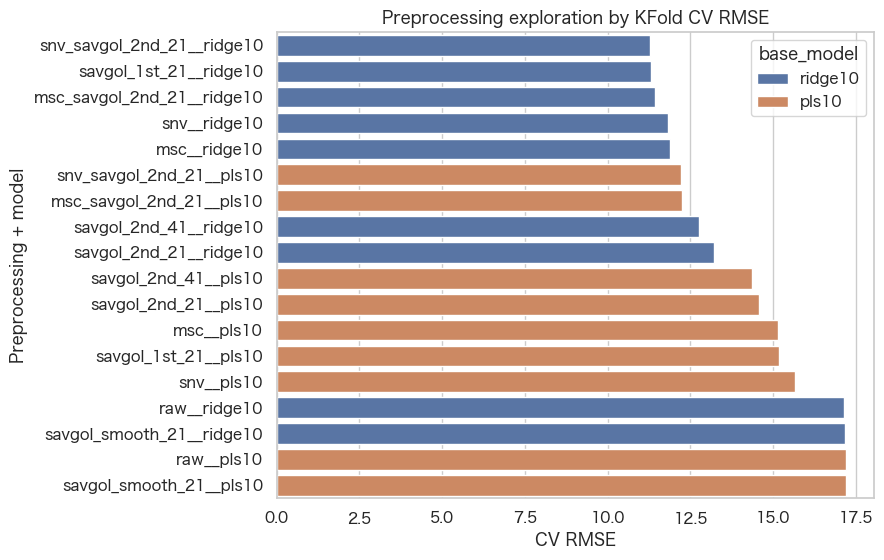

In [9]:
preprocessing_candidates = {
    'raw': [],
    'savgol_smooth_21': [('savgol', SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=0))],
    'savgol_1st_21': [('savgol', SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=1))],
    'savgol_2nd_21': [('savgol', SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2))],
    'savgol_2nd_41': [('savgol', SavitzkyGolayTransformer(window_length=41, polyorder=2, deriv=2))],
    'snv': [('snv', SNVTransformer())],
    'snv_savgol_2nd_21': [('snv', SNVTransformer()), ('savgol', SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2))],
    'msc': [('msc', MSCTransformer())],
    'msc_savgol_2nd_21': [('msc', MSCTransformer()), ('savgol', SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2))],
}


def make_cv(X):
    return KFold(n_splits=min(N_SPLITS, len(X)), shuffle=True, random_state=RANDOM_STATE)


def evaluate_cv(estimator, X, y, model_name, cv=None, sample_id_values=None, diagnostic_group_values=None):
    cv = cv or make_cv(X)
    oof = np.full(len(y), np.nan, dtype=float)
    fold_rows = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        est = clone(estimator)
        est.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = np.asarray(est.predict(X.iloc[va_idx])).ravel()
        oof[va_idx] = pred
        fold_rows.append({'model_name': model_name, 'fold': fold, 'n_train': len(tr_idx), 'n_valid': len(va_idx), **regression_metrics(y.iloc[va_idx], pred)})
    score = {'model_name': model_name, **regression_metrics(y, oof)}
    oof_part = pd.DataFrame({
        'sample_id': sample_id_values if sample_id_values is not None else np.arange(len(y)),
        'model_name': model_name,
        'y_true': y.values,
        'oof_pred': oof,
    })
    if diagnostic_group_values is not None:
        oof_part['diagnostic_group'] = diagnostic_group_values
    return score, pd.DataFrame(fold_rows), oof_part


def build_fixed_model(model_key):
    if model_key == 'pls10':
        return AdaptivePLSRegression(n_components=10, scale=True)
    if model_key == 'ridge10':
        return Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=10.0))])
    raise KeyError(model_key)


def build_fixed_pipeline(prep_name, model_key, selector=None):
    steps = []
    if selector is not None:
        steps.append(('select_wavelengths', selector))
    steps.extend(preprocessing_candidates[prep_name])
    model = build_fixed_model(model_key)
    if isinstance(model, Pipeline):
        steps.extend([(f'{model_key}_{name}', step) for name, step in model.steps])
    else:
        steps.append((model_key, model))
    return Pipeline(steps)

if RUN_PREPROCESSING_EXPLORATION:
    prep_rows = []
    for prep_name in preprocessing_candidates:
        for model_key in ['pls10', 'ridge10']:
            name = f'{prep_name}__{model_key}'
            print(name)
            try:
                score, _, _ = evaluate_cv(build_fixed_pipeline(prep_name, model_key), X_train, y_train, name)
                score.update({'preprocessing': prep_name, 'base_model': model_key})
                prep_rows.append(score)
            except Exception as exc:
                prep_rows.append({'model_name': name, 'preprocessing': prep_name, 'base_model': model_key, 'r2': np.nan, 'rmse': np.nan, 'mae': np.nan, 'error': repr(exc)})
    prep_scores = pd.DataFrame(prep_rows).sort_values('rmse')
    preprocessing_summary = (
        prep_scores.dropna(subset=['rmse'])
        .groupby('preprocessing', as_index=False)
        .agg(best_rmse=('rmse', 'min'), median_rmse=('rmse', 'median'), best_r2=('r2', 'max'), n_success=('rmse', 'count'))
        .sort_values(['best_rmse', 'median_rmse'])
    )
    selected_preprocessings = preprocessing_summary.head(TOP_PREPROCESSINGS_FOR_MODEL_SEARCH)['preprocessing'].tolist()
    selected_preprocessings = list(dict.fromkeys(selected_preprocessings + [p for p in ALWAYS_INCLUDE_PREPROCESSINGS if p in preprocessing_candidates]))
    if not selected_preprocessings:
        selected_preprocessings = FALLBACK_MODEL_SEARCH_PREPROCESSINGS.copy()
    prep_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_preprocessing_scores_cv.csv', index=False, encoding='utf-8-sig')
    preprocessing_summary.to_csv(OUTPUT_DIR / f'{PREFIX}_preprocessing_summary.csv', index=False, encoding='utf-8-sig')
    display(prep_scores.head(20))
    display(preprocessing_summary)
    print('selected preprocessings for full-wavelength model search:', selected_preprocessings)
    write_run_config({'selected_preprocessings': selected_preprocessings, 'preprocessing_summary': preprocessing_summary.to_dict(orient='records')})

    fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(prep_scores))))
    sns.barplot(data=prep_scores, y='model_name', x='rmse', hue='base_model', dodge=False, ax=ax)
    ax.set_title('Preprocessing exploration by KFold CV RMSE')
    ax.set_xlabel('CV RMSE')
    ax.set_ylabel('Preprocessing + model')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{PREFIX}_preprocessing_cv_rmse.png', dpi=160)
else:
    prep_scores = pd.DataFrame()
    preprocessing_summary = pd.DataFrame()
    selected_preprocessings = FALLBACK_MODEL_SEARCH_PREPROCESSINGS.copy()
    print('preprocessing exploration skipped; fallback preprocessings:', selected_preprocessings)
    write_run_config({'selected_preprocessings': selected_preprocessings})


## 3. 全波長モデル探索

前処理探索で選ばれた `selected_preprocessings` だけを使い、全波長を入力して KFold の各外側 fold で学習データだけを使う GridSearchCV を回します。前処理数を絞る代わりに、PLS/Ridge/ElasticNet/SVR/KNN/GPR/決定木/RandomForest/ExtraTrees/GradientBoosting/HistGradientBoosting のハイパーパラメータ候補を厚めにして、モデル側の網羅性を確保します。


In [10]:
def _grid_by_mode(mode, quick, standard, exhaustive):
    if mode == 'quick':
        return quick
    if mode == 'standard':
        return standard
    if mode == 'exhaustive':
        return exhaustive
    raise ValueError(f'Unknown SEARCH_MODE={mode}')


def model_search_space(model_key, mode=SEARCH_MODE):
    if model_key == 'pls':
        return AdaptivePLSRegression(scale=True), {
            'n_components': _grid_by_mode(mode, [5, 10, 15], [2, 3, 5, 8, 10, 12, 15, 20], [2, 3, 5, 8, 10, 12, 15, 20, 30])
        }
    if model_key == 'ridge':
        return Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())]), {
            'ridge__alpha': _grid_by_mode(mode, [0.1, 1.0, 10.0, 100.0], [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0], [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0])
        }
    if model_key == 'elasticnet':
        return Pipeline([('scaler', StandardScaler()), ('elasticnet', ElasticNet(max_iter=30000, random_state=RANDOM_STATE))]), {
            'elasticnet__alpha': _grid_by_mode(mode, [0.001, 0.01, 0.1], [0.001, 0.003, 0.01, 0.03, 0.1], [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]),
            'elasticnet__l1_ratio': _grid_by_mode(mode, [0.1, 0.5, 0.9], [0.1, 0.3, 0.5, 0.7, 0.9], [0.05, 0.1, 0.3, 0.5, 0.7, 0.9]),
        }
    if model_key == 'svr':
        return Pipeline([('scaler', StandardScaler()), ('svr', SVR())]), {
            'svr__C': _grid_by_mode(mode, [1.0, 10.0, 100.0], [0.3, 1.0, 3.0, 10.0, 30.0, 100.0], [0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0]),
            'svr__epsilon': _grid_by_mode(mode, [0.1, 0.3], [0.03, 0.1, 0.3], [0.01, 0.03, 0.1, 0.3, 0.6]),
            'svr__gamma': _grid_by_mode(mode, ['scale'], ['scale', 'auto', 0.003, 0.01], ['scale', 'auto', 0.001, 0.003, 0.01, 0.03]),
        }
    if model_key == 'knn':
        return Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor())]), {
            'knn__n_neighbors': _grid_by_mode(mode, [5, 11, 21], [3, 5, 7, 11, 15, 21], [3, 5, 7, 9, 11, 15, 21, 31]),
            'knn__weights': ['uniform', 'distance'],
            'knn__p': [1, 2],
        }
    if model_key == 'gpr':
        length_scales = _grid_by_mode(mode, [1.0], [0.3, 1.0, 3.0], [0.3, 1.0, 3.0])
        noise_levels = _grid_by_mode(mode, [1.0], [0.1, 1.0], [0.1, 1.0])
        kernels = [
            ConstantKernel(1.0, constant_value_bounds='fixed') * RBF(length_scale=ls, length_scale_bounds='fixed') + WhiteKernel(noise_level=noise, noise_level_bounds='fixed')
            for ls in length_scales
            for noise in noise_levels
        ]
        return Pipeline([('scaler', StandardScaler()), ('gpr', GaussianProcessRegressor(normalize_y=True, random_state=RANDOM_STATE))]), {
            'gpr__kernel': kernels,
            'gpr__alpha': _grid_by_mode(mode, [1e-6, 1e-4], [1e-6, 1e-4, 1e-2], [1e-8, 1e-6, 1e-4, 1e-2]),
        }
    if model_key == 'decision_tree':
        return DecisionTreeRegressor(random_state=RANDOM_STATE), {
            'criterion': _grid_by_mode(mode, ['squared_error'], ['squared_error', 'friedman_mse'], ['squared_error', 'friedman_mse', 'absolute_error']),
            'max_depth': _grid_by_mode(mode, [5, None], [3, 5, 8, None], [3, 5, 8, 12, None]),
            'min_samples_split': _grid_by_mode(mode, [2, 10], [2, 5, 10], [2, 5, 10]),
            'min_samples_leaf': _grid_by_mode(mode, [2, 10], [1, 2, 5, 10], [1, 2, 5, 10, 20]),
        }
    if model_key == 'random_forest':
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), {
            'n_estimators': _grid_by_mode(mode, [300], [300, 600], [300, 600]),
            'max_features': _grid_by_mode(mode, ['sqrt', 0.7], ['sqrt', 'log2', 0.5, 1.0], ['sqrt', 'log2', 0.4, 0.7, 1.0]),
            'min_samples_leaf': _grid_by_mode(mode, [2, 5], [1, 2, 5], [1, 2, 3, 5, 10]),
            'bootstrap': [True],
        }
    if model_key == 'extra_trees':
        return ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1), {
            'n_estimators': _grid_by_mode(mode, [300], [300, 600], [300, 600]),
            'max_features': _grid_by_mode(mode, ['sqrt', 0.7], ['sqrt', 'log2', 0.5, 1.0], ['sqrt', 'log2', 0.4, 0.7, 1.0]),
            'min_samples_leaf': _grid_by_mode(mode, [2, 5], [1, 2, 5], [1, 2, 5, 10]),
        }
    if model_key == 'gradient_boosting':
        return GradientBoostingRegressor(random_state=RANDOM_STATE), {
            'n_estimators': _grid_by_mode(mode, [150, 300], [150, 300], [150, 300, 500]),
            'learning_rate': _grid_by_mode(mode, [0.03, 0.1], [0.03, 0.06, 0.1], [0.02, 0.03, 0.06, 0.1]),
            'max_depth': _grid_by_mode(mode, [2, 3], [2, 3], [2, 3, 4]),
            'min_samples_leaf': _grid_by_mode(mode, [2, 5], [1, 2, 5], [1, 2, 5, 10]),
            'subsample': _grid_by_mode(mode, [1.0], [0.7, 1.0], [0.7, 1.0]),
        }
    if model_key == 'hist_gradient_boosting':
        return HistGradientBoostingRegressor(random_state=RANDOM_STATE), {
            'max_iter': _grid_by_mode(mode, [150], [150, 300], [150, 300, 500]),
            'learning_rate': _grid_by_mode(mode, [0.05, 0.1], [0.02, 0.05, 0.1], [0.02, 0.05, 0.1]),
            'max_leaf_nodes': _grid_by_mode(mode, [31], [15, 31], [15, 31, 63]),
            'min_samples_leaf': _grid_by_mode(mode, [20], [10, 20, 40], [10, 20, 40]),
            'l2_regularization': _grid_by_mode(mode, [0.0], [0.0, 0.01], [0.0, 0.01, 0.1]),
        }
    raise KeyError(model_key)


def model_search_space_summary():
    rows = []
    for key in MODEL_SEARCH_KEYS:
        _, grid = model_search_space(key)
        n_candidates = int(np.prod([len(v) for v in grid.values()])) if grid else 1
        rows.append({'model_key': key, 'n_hyperparameter_candidates': n_candidates, 'param_grid': grid})
    return pd.DataFrame(rows)


def build_tuned_pipeline(prep_name, model_key, selector=None):
    estimator, param_grid = model_search_space(model_key)
    search = GridSearchCV(
        estimator,
        param_grid=param_grid,
        cv=INNER_SEARCH_CV,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        refit=True,
    )
    steps = []
    if selector is not None:
        steps.append(('select_wavelengths', selector))
    steps.extend(preprocessing_candidates[prep_name])
    steps.append(('search', search))
    return Pipeline(steps)

search_space_df = model_search_space_summary()
search_space_df.to_csv(OUTPUT_DIR / f'{PREFIX}_model_search_space.csv', index=False, encoding='utf-8-sig')
write_run_config({'model_search_keys': MODEL_SEARCH_KEYS, 'model_search_space': search_space_df.to_dict(orient='records')})
display(search_space_df[['model_key', 'n_hyperparameter_candidates']])

candidate_registry = {}
full_search_scores = pd.DataFrame()
fold_scores_df = pd.DataFrame()
oof_df = pd.DataFrame()

if RUN_FULL_WAVELENGTH_MODEL_SEARCH:
    score_rows = []
    fold_parts = []
    oof_parts = []
    search_preprocessings = [p for p in selected_preprocessings if p in preprocessing_candidates]
    if not search_preprocessings:
        search_preprocessings = FALLBACK_MODEL_SEARCH_PREPROCESSINGS.copy()
    print('full-wavelength search preprocessings:', search_preprocessings)
    items = [(prep, model) for prep in search_preprocessings for model in MODEL_SEARCH_KEYS]
    sample_id_values = sample_ids(train_df, sample_col)
    diagnostic_values = train_df[group_col].astype(str).values if group_col is not None and group_col in train_df.columns else None
    for i, (prep_name, model_key) in enumerate(items, start=1):
        name = f'full__{prep_name}__tuned_{model_key}'
        print(f'[{i:02d}/{len(items)}] {name}')
        est = build_tuned_pipeline(prep_name, model_key)
        candidate_registry[name] = est
        try:
            score, fold_df, oof_part = evaluate_cv(est, X_train, y_train, name, sample_id_values=sample_id_values, diagnostic_group_values=diagnostic_values)
            score.update({'stage': 'full_wavelength', 'preprocessing': prep_name, 'model_key': model_key, 'wavelength_set': 'all'})
            score_rows.append(score)
            fold_parts.append(fold_df)
            oof_parts.append(oof_part)
        except Exception as exc:
            score_rows.append({'model_name': name, 'stage': 'full_wavelength', 'preprocessing': prep_name, 'model_key': model_key, 'wavelength_set': 'all', 'r2': np.nan, 'rmse': np.nan, 'mae': np.nan, 'error': repr(exc)})
    full_search_scores = pd.DataFrame(score_rows).sort_values('rmse')
    fold_scores_df = pd.concat(fold_parts, ignore_index=True) if fold_parts else pd.DataFrame()
    oof_df = pd.concat(oof_parts, ignore_index=True) if oof_parts else pd.DataFrame()
    full_search_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_full_wavelength_model_scores_cv.csv', index=False, encoding='utf-8-sig')
    fold_scores_df.to_csv(OUTPUT_DIR / f'{PREFIX}_fold_scores_cv.csv', index=False, encoding='utf-8-sig')
    oof_df.to_csv(OUTPUT_DIR / f'{PREFIX}_oof_predictions.csv', index=False, encoding='utf-8-sig')
    display(full_search_scores.head(30))
else:
    full_search_scores = pd.DataFrame()


,model_key,n_hyperparameter_candidates
0,pls,3
1,ridge,4
2,svr,6
3,knn,12
4,random_forest,4


full-wavelength search preprocessings: ['snv_savgol_2nd_21', 'savgol_1st_21', 'raw']
[01/15] full__snv_savgol_2nd_21__tuned_pls
[02/15] full__snv_savgol_2nd_21__tuned_ridge
[03/15] full__snv_savgol_2nd_21__tuned_svr
[04/15] full__snv_savgol_2nd_21__tuned_knn
[05/15] full__snv_savgol_2nd_21__tuned_random_forest
[06/15] full__savgol_1st_21__tuned_pls
[07/15] full__savgol_1st_21__tuned_ridge
[08/15] full__savgol_1st_21__tuned_svr
[09/15] full__savgol_1st_21__tuned_knn
[10/15] full__savgol_1st_21__tuned_random_forest
[11/15] full__raw__tuned_pls
[12/15] full__raw__tuned_ridge
[13/15] full__raw__tuned_svr
[14/15] full__raw__tuned_knn
[15/15] full__raw__tuned_random_forest


,model_name,r2,rmse,mae,stage,preprocessing,model_key,wavelength_set
7,full__savgol_1st_21__tuned_svr,0.987435,5.441828,2.522010,full_wavelength,savgol_1st_21,svr,all
8,full__savgol_1st_21__tuned_knn,0.982610,6.402035,3.052512,full_wavelength,savgol_1st_21,knn,all
9,full__savgol_1st_21__tuned_random_forest,0.972902,7.991640,3.903513,full_wavelength,savgol_1st_21,random_forest,all
3,full__snv_savgol_2nd_21__tuned_knn,0.964420,9.157309,4.406085,full_wavelength,snv_savgol_2nd_21,knn,all
4,full__snv_savgol_2nd_21__tuned_random_forest,0.958810,9.852828,4.865946,full_wavelength,snv_savgol_2nd_21,random_forest,all
1,full__snv_savgol_2nd_21__tuned_ridge,0.947301,11.144711,7.866448,full_wavelength,snv_savgol_2nd_21,ridge,all
6,full__savgol_1st_21__tuned_ridge,0.946220,11.258442,7.894159,full_wavelength,savgol_1st_21,ridge,all
2,full__snv_savgol_2nd_21__tuned_svr,0.943259,11.564211,4.954350,full_wavelength,snv_savgol_2nd_21,svr,all
5,full__savgol_1st_21__tuned_pls,0.931283,12.726217,9.167316,full_wavelength,savgol_1st_21,pls,all
0,full__snv_savgol_2nd_21__tuned_pls,0.919718,13.755462,9.548037,full_wavelength,snv_savgol_2nd_21,pls,all


### 3.1 全波長モデル探索の実測/推測散布図

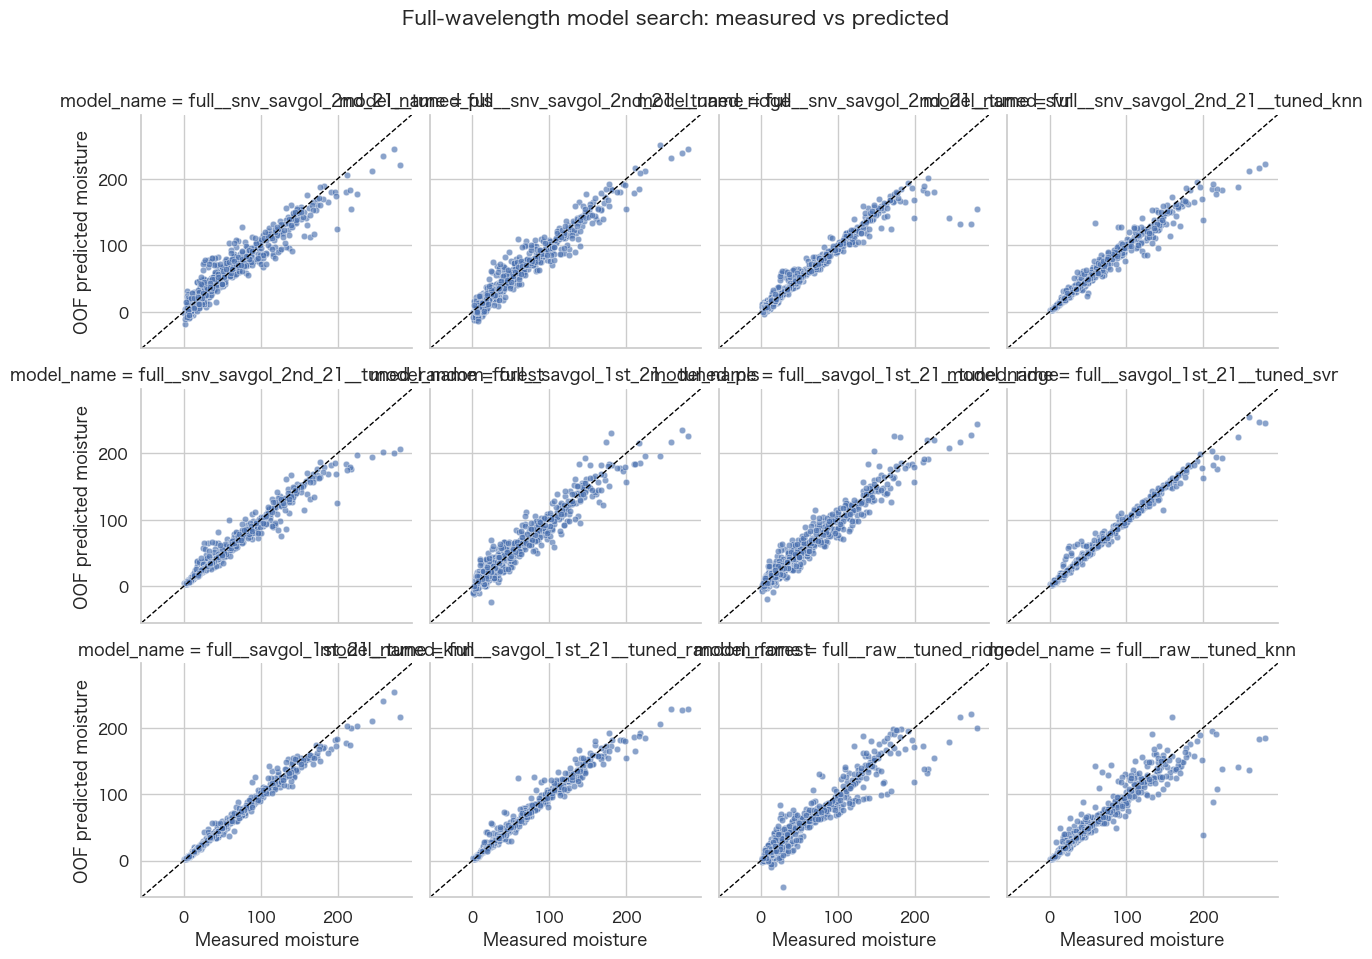

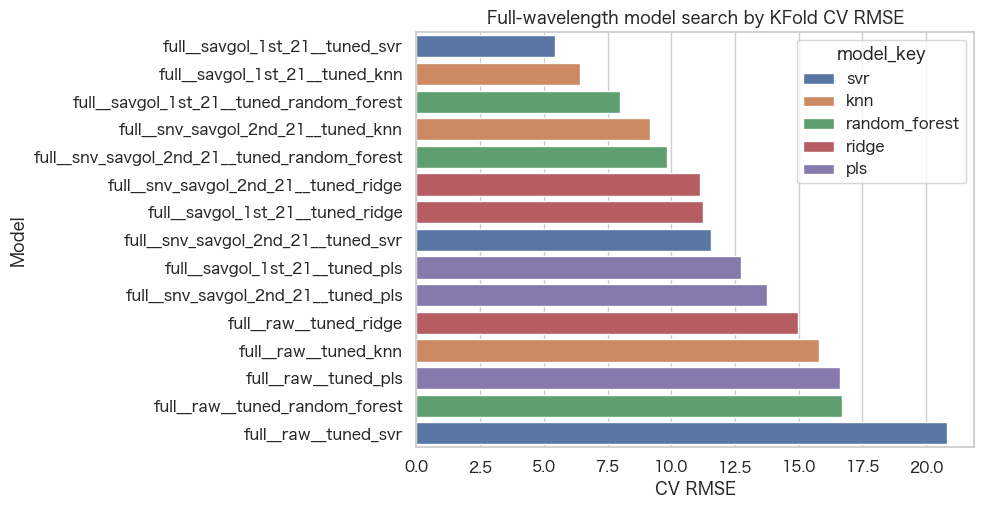

In [11]:
def plot_oof_scatter_for_models(oof_df, scores_df, out_prefix, top_n=12):
    top_models = [m for m in scores_df.dropna(subset=['rmse']).head(top_n)['model_name'] if m in set(oof_df['model_name'])]
    if not top_models:
        return pd.DataFrame()
    plot_df = oof_df[oof_df['model_name'].isin(top_models)].copy()
    plot_df['residual'] = plot_df['y_true'] - plot_df['oof_pred']
    g = sns.FacetGrid(plot_df, col='model_name', col_wrap=4, height=3.1, sharex=True, sharey=True)
    g.map_dataframe(sns.scatterplot, x='y_true', y='oof_pred', s=22, alpha=0.65)
    low = min(plot_df['y_true'].min(), plot_df['oof_pred'].min())
    high = max(plot_df['y_true'].max(), plot_df['oof_pred'].max())
    pad = (high - low) * 0.05 if high > low else 1
    for ax in g.axes.flat:
        ax.plot([low - pad, high + pad], [low - pad, high + pad], color='black', linestyle='--', linewidth=1)
        ax.set_xlim(low - pad, high + pad)
        ax.set_ylim(low - pad, high + pad)
    g.set_axis_labels('Measured moisture', 'OOF predicted moisture')
    g.fig.suptitle('Full-wavelength model search: measured vs predicted', y=1.03)
    g.fig.tight_layout()
    g.fig.savefig(FIGURE_DIR / f'{out_prefix}_full_wavelength_top_oof_scatter.png', dpi=160)
    plot_df.to_csv(OUTPUT_DIR / f'{out_prefix}_full_wavelength_top_oof_predictions_for_plot.csv', index=False, encoding='utf-8-sig')
    return plot_df

full_oof_plot_df = plot_oof_scatter_for_models(oof_df, full_search_scores, PREFIX, top_n=12) if not oof_df.empty else pd.DataFrame()

if not full_search_scores.empty:
    score_plot = full_search_scores.dropna(subset=['rmse']).head(25).copy()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(score_plot))))
    sns.barplot(data=score_plot, y='model_name', x='rmse', hue='model_key', dodge=False, ax=ax)
    ax.set_title('Full-wavelength model search by KFold CV RMSE')
    ax.set_xlabel('CV RMSE')
    ax.set_ylabel('Model')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{PREFIX}_full_wavelength_cv_rmse.png', dpi=160)


## 4. 波長区間選択

全波長モデル探索 `full_search_scores` の上位モデル構成だけを使い、単一区間と複数区間の組み合わせを評価します。単一区間はスペクトル軸全体から中〜広めの幅で自動生成し、2-3区間の組み合わせは重なりが大きすぎる候補を避けて作ります。実際に評価する区間候補は `04_advanced_interval_candidates.csv` に保存し、notebook上にも表示します。


In [12]:
def interval_to_columns(wavelengths, start_nm, end_nm):
    w = np.asarray(wavelengths, dtype=float)
    lo, hi = sorted([float(start_nm), float(end_nm)])
    return np.where((w >= lo) & (w <= hi))[0]


def _nice_interval_value(value, span):
    base = 50 if span <= 2500 else 100
    return int(max(base, round(float(value) / base) * base))


def _infer_axis_unit_for_intervals(values):
    values = np.asarray(values, dtype=float)
    if 'SPECTRAL_AXIS_UNIT' in globals() and SPECTRAL_AXIS_UNIT != 'auto':
        return SPECTRAL_AXIS_UNIT
    return 'cm-1' if np.nanmedian(values) > 2500 else 'nm'


def _domain_intervals_for_axis(wavelengths):
    axis_unit = _infer_axis_unit_for_intervals(wavelengths)
    if axis_unit == 'cm-1':
        # Broad NIR / short-wave IR wavenumber regions. Adjust if your instrument covers a different domain.
        return [
            (4000, 5000),
            (5000, 6000),
            (6000, 7500),
            (7500, 9000),
            (9000, 10000),
            (5200, 7200),
            (7000, 9000),
            (4000, 6000),
            (6000, 9000),
        ]
    return [
        (900, 1200),
        (1000, 1600),
        (1100, 1500),
        (1200, 1400),
        (1300, 1700),
        (1450, 1600),
        (900, 1100),
        (1100, 1300),
        (1300, 1500),
        (1500, 1700),
    ]


def build_interval_library(wavelengths):
    values = np.asarray(wavelengths, dtype=float)
    axis_min = float(np.nanmin(values))
    axis_max = float(np.nanmax(values))
    span = axis_max - axis_min
    step = _nice_interval_value(span / 30, span)
    widths = sorted({
        _nice_interval_value(span * ratio, span)
        for ratio in [0.08, 0.12, 0.18, 0.25, 0.35]
    })
    wmin = int(np.floor(axis_min / step) * step)
    wmax = int(np.ceil(axis_max / step) * step)
    records = []
    for width in widths:
        for start in range(wmin, wmax - width + 1, step):
            end = start + width
            cols = interval_to_columns(wavelengths, start, end)
            if len(cols) >= 8:
                records.append({
                    'label': f'{start}-{end}',
                    'kind': 'single_sliding',
                    'ranges': [(start, end)],
                    'columns': tuple(cols),
                    'width': int(width),
                    'combo_size': 1,
                })
    for start, end in _domain_intervals_for_axis(wavelengths):
        cols = interval_to_columns(wavelengths, start, end)
        if len(cols) >= 8:
            records.append({
                'label': f'{start}-{end}',
                'kind': 'single_domain',
                'ranges': [(start, end)],
                'columns': tuple(cols),
                'width': int(abs(end - start)),
                'combo_size': 1,
            })
    unique = {}
    for rec in records:
        unique.setdefault(rec['columns'], rec)
    return list(unique.values())


def _combined_record(records, kind):
    labels = [r['label'] for r in records]
    ranges = sum([r['ranges'] for r in records], [])
    cols = tuple(sorted(set().union(*[set(r['columns']) for r in records])))
    return {
        'label': '+'.join(labels),
        'kind': kind,
        'ranges': ranges,
        'columns': cols,
        'width': int(sum(r.get('width', 0) for r in records)),
        'combo_size': len(records),
    }


def _overlap_ratio(records):
    total = sum(len(r['columns']) for r in records)
    union = len(set().union(*[set(r['columns']) for r in records]))
    if total == 0:
        return 1.0
    return 1 - union / total


def _max_smaller_overlap_fraction(records):
    max_frac = 0.0
    for i, r1 in enumerate(records):
        c1 = set(r1['columns'])
        for r2 in records[i + 1:]:
            c2 = set(r2['columns'])
            denom = max(1, min(len(c1), len(c2)))
            max_frac = max(max_frac, len(c1.intersection(c2)) / denom)
    return max_frac


def _representative_interval_source(records, max_source=36):
    singles = [r for r in records if r.get('combo_size', 1) == 1]
    if len(singles) <= max_source:
        return singles
    # Prefer a balanced source across centers and widths, not only the smallest/leftmost intervals.
    ranked = sorted(
        singles,
        key=lambda r: (
            (np.mean([a + b for a, b in r['ranges']]) / 2),
            r.get('width', 0),
        ),
    )
    idx = np.linspace(0, len(ranked) - 1, max_source).round().astype(int)
    return [ranked[i] for i in sorted(set(idx))]


def combine_interval_records(records, max_combinations=MAX_INTERVAL_COMBINATIONS):
    # Keep a balanced subset of single intervals, then reserve room for 2-3 region combinations.
    single_limit = min(len(records), max(8, int(max_combinations * 0.40)))
    combined = _representative_interval_source(records, max_source=single_limit)
    by_label = {r['label']: r for r in records}

    # Explicit domain-style combinations. These are only used when the labels exist for the current axis.
    explicit_groups = [
        ['1000-1600', '1200-1400'],
        ['900-1200', '1300-1700'],
        ['1000-1200', '1400-1600'],
        ['1100-1300', '1450-1600'],
        ['4000-5000', '6000-7500'],
        ['5000-6000', '7500-9000'],
        ['4000-5000', '6000-7500', '9000-10000'],
        ['5200-7200', '7000-9000'],
    ]
    for labels in explicit_groups:
        picked = [by_label[x] for x in labels if x in by_label]
        if len(picked) >= 2:
            combined.append(_combined_record(picked, kind='combo_explicit'))

    source = _representative_interval_source(records, max_source=40)
    candidate_by_size = {2: [], 3: []}
    for combo_size in [2, 3]:
        for combo in combinations(source, combo_size):
            # Avoid nested or almost-identical intervals; keep genuinely separated or complementary regions.
            if _overlap_ratio(combo) > (0.15 if combo_size == 2 else 0.22):
                continue
            if _max_smaller_overlap_fraction(combo) > 0.50:
                continue
            rec = _combined_record(combo, kind=f'combo_{combo_size}_regions')
            coverage = len(rec['columns']) / max(1, len(set().union(*[set(r['columns']) for r in records])))
            target_coverage = 0.35 if combo_size == 2 else 0.45
            centers = [np.mean([a + b for a, b in r['ranges']]) / 2 for r in combo]
            center_spread = max(centers) - min(centers)
            candidate_by_size[combo_size].append((abs(coverage - target_coverage), -center_spread, -coverage, rec))
    for combo_size in candidate_by_size:
        candidate_by_size[combo_size] = sorted(candidate_by_size[combo_size], key=lambda x: (x[0], x[1], x[2]))

    remaining_slots = max_combinations - len(combined)
    two_target = max(0, remaining_slots // 2)
    three_target = max(0, remaining_slots - two_target)
    combo_plan = [(2, two_target), (3, three_target), (2, 10_000), (3, 10_000)]
    for combo_size, limit in combo_plan:
        used = 0
        for _, _, _, rec in candidate_by_size[combo_size]:
            combined.append(rec)
            used += 1
            if len(combined) >= max_combinations or used >= limit:
                break
        if len(combined) >= max_combinations:
            break

    unique = {}
    for rec in combined:
        unique.setdefault(rec['columns'], rec)
    result = list(unique.values())
    singles = [r for r in result if r.get('combo_size', 1) == 1]
    combos2 = [r for r in result if r.get('combo_size', 1) == 2]
    combos3 = [r for r in result if r.get('combo_size', 1) == 3]
    return (singles[:single_limit] + combos2 + combos3)[:max_combinations]


def interval_records_to_frame(records, wavelengths):
    rows = []
    w = np.asarray(wavelengths, dtype=float)
    for i, rec in enumerate(records, start=1):
        cols = np.asarray(rec['columns'], dtype=int)
        rows.append({
            'interval_id': i,
            'label': rec['label'],
            'kind': rec.get('kind', ''),
            'combo_size': rec.get('combo_size', len(rec.get('ranges', []))),
            'ranges': json.dumps(rec['ranges'], ensure_ascii=False),
            'n_selected_wavelengths': int(len(cols)),
            'axis_min': float(np.min(w[cols])) if len(cols) else np.nan,
            'axis_max': float(np.max(w[cols])) if len(cols) else np.nan,
        })
    return pd.DataFrame(rows)


def parse_stage_model(row):
    return row['preprocessing'], row['model_key']

interval_scores_df = pd.DataFrame()
interval_oof_df = pd.DataFrame()

if RUN_INTERVAL_SELECTION and not full_search_scores.empty:
    interval_records = combine_interval_records(build_interval_library(wavelengths))
    interval_candidates_df = interval_records_to_frame(interval_records, wavelengths)
    interval_candidates_df.to_csv(OUTPUT_DIR / f'{PREFIX}_interval_candidates.csv', index=False, encoding='utf-8-sig')
    display(interval_candidates_df)
    top_configs = full_search_scores.dropna(subset=['rmse']).head(TOP_MODELS_FOR_INTERVAL_SELECTION)
    interval_rows = []
    interval_fold_parts = []
    interval_oof_parts = []
    total = len(interval_records) * len(top_configs)
    count = 0
    sample_id_values = sample_ids(train_df, sample_col)
    diagnostic_values = train_df[group_col].astype(str).values if group_col is not None and group_col in train_df.columns else None
    for _, row in top_configs.iterrows():
        prep_name, model_key = parse_stage_model(row)
        for rec in interval_records:
            count += 1
            selector = ColumnSelector(rec['columns'])
            name = f"interval__{rec['label']}__{prep_name}__tuned_{model_key}"
            print(f'[{count:03d}/{total}] {name}')
            est = build_tuned_pipeline(prep_name, model_key, selector=selector)
            candidate_registry[name] = est
            try:
                score, fold_df, oof_part = evaluate_cv(est, X_train, y_train, name, sample_id_values=sample_id_values, diagnostic_group_values=diagnostic_values)
                score.update({
                    'stage': 'interval_selection',
                    'preprocessing': prep_name,
                    'model_key': model_key,
                    'wavelength_set': rec['label'],
                    'interval_kind': rec.get('kind', ''),
                    'combo_size': rec.get('combo_size', len(rec.get('ranges', []))),
                    'interval_ranges': json.dumps(rec['ranges'], ensure_ascii=False),
                    'n_selected_wavelengths': len(rec['columns']),
                    'source_full_model': row['model_name'],
                })
                interval_rows.append(score)
                interval_fold_parts.append(fold_df)
                interval_oof_parts.append(oof_part)
            except Exception as exc:
                interval_rows.append({'model_name': name, 'stage': 'interval_selection', 'preprocessing': prep_name, 'model_key': model_key, 'wavelength_set': rec['label'], 'interval_kind': rec.get('kind', ''), 'combo_size': rec.get('combo_size', np.nan), 'rmse': np.nan, 'r2': np.nan, 'mae': np.nan, 'error': repr(exc)})
    interval_scores_df = pd.DataFrame(interval_rows).sort_values('rmse')
    interval_oof_df = pd.concat(interval_oof_parts, ignore_index=True) if interval_oof_parts else pd.DataFrame()
    interval_scores_df.to_csv(OUTPUT_DIR / f'{PREFIX}_interval_selection_scores_cv.csv', index=False, encoding='utf-8-sig')
    interval_oof_df.to_csv(OUTPUT_DIR / f'{PREFIX}_interval_selection_oof_predictions.csv', index=False, encoding='utf-8-sig')
    display(interval_scores_df.head(30))

    all_score_frames = [full_search_scores, interval_scores_df]
    all_oof_frames = [oof_df, interval_oof_df]
    model_scores = pd.concat(all_score_frames, ignore_index=True, sort=False).sort_values('rmse')
    oof_df = pd.concat(all_oof_frames, ignore_index=True, sort=False)
    model_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_model_scores_cv.csv', index=False, encoding='utf-8-sig')
    oof_df.to_csv(OUTPUT_DIR / f'{PREFIX}_all_oof_predictions.csv', index=False, encoding='utf-8-sig')
else:
    interval_records = combine_interval_records(build_interval_library(wavelengths))
    interval_candidates_df = interval_records_to_frame(interval_records, wavelengths)
    interval_candidates_df.to_csv(OUTPUT_DIR / f'{PREFIX}_interval_candidates.csv', index=False, encoding='utf-8-sig')
    display(interval_candidates_df)
    model_scores = full_search_scores.copy()

[001/90] interval__4000-4100__savgol_1st_21__tuned_svr
[002/90] interval__4100-4200__savgol_1st_21__tuned_svr
[003/90] interval__4200-4300__savgol_1st_21__tuned_svr
[004/90] interval__4300-4400__savgol_1st_21__tuned_svr
[005/90] interval__4400-4500__savgol_1st_21__tuned_svr
[006/90] interval__4500-4600__savgol_1st_21__tuned_svr
[007/90] interval__4600-4700__savgol_1st_21__tuned_svr
[008/90] interval__4700-4800__savgol_1st_21__tuned_svr
[009/90] interval__4800-4900__savgol_1st_21__tuned_svr
[010/90] interval__4900-5000__savgol_1st_21__tuned_svr
[011/90] interval__5000-5100__savgol_1st_21__tuned_svr
[012/90] interval__5100-5200__savgol_1st_21__tuned_svr
[013/90] interval__5200-5300__savgol_1st_21__tuned_svr
[014/90] interval__5300-5400__savgol_1st_21__tuned_svr
[015/90] interval__5400-5500__savgol_1st_21__tuned_svr
[016/90] interval__5500-5600__savgol_1st_21__tuned_svr
[017/90] interval__5600-5700__savgol_1st_21__tuned_svr
[018/90] interval__5700-5800__savgol_1st_21__tuned_svr
[019/90] i

/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/

[073/90] interval__5200-5300__savgol_1st_21__tuned_random_forest
[074/90] interval__5300-5400__savgol_1st_21__tuned_random_forest


/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/

[075/90] interval__5400-5500__savgol_1st_21__tuned_random_forest
[076/90] interval__5500-5600__savgol_1st_21__tuned_random_forest
[077/90] interval__5600-5700__savgol_1st_21__tuned_random_forest
[078/90] interval__5700-5800__savgol_1st_21__tuned_random_forest
[079/90] interval__5800-5900__savgol_1st_21__tuned_random_forest
[080/90] interval__5900-6000__savgol_1st_21__tuned_random_forest
[081/90] interval__6000-6100__savgol_1st_21__tuned_random_forest
[082/90] interval__6100-6200__savgol_1st_21__tuned_random_forest
[083/90] interval__6200-6300__savgol_1st_21__tuned_random_forest
[084/90] interval__6300-6400__savgol_1st_21__tuned_random_forest
[085/90] interval__6400-6500__savgol_1st_21__tuned_random_forest
[086/90] interval__6500-6600__savgol_1st_21__tuned_random_forest
[087/90] interval__6600-6700__savgol_1st_21__tuned_random_forest
[088/90] interval__6700-6800__savgol_1st_21__tuned_random_forest
[089/90] interval__6800-6900__savgol_1st_21__tuned_random_forest
[090/90] interval__6900-7

,model_name,r2,rmse,mae,stage,preprocessing,model_key,wavelength_set,interval_ranges,n_selected_wavelengths,source_full_model
39,interval__4900-5000__savgol_1st_21__tuned_knn,0.913549,14.274216,8.020809,interval_selection,savgol_1st_21,knn,4900-5000,"[[4900, 5000]]",26,full__savgol_1st_21__tuned_knn
37,interval__4700-4800__savgol_1st_21__tuned_knn,0.911856,14.413236,8.773087,interval_selection,savgol_1st_21,knn,4700-4800,"[[4700, 4800]]",26,full__savgol_1st_21__tuned_knn
69,interval__4900-5000__savgol_1st_21__tuned_rand...,0.910924,14.489256,8.752088,interval_selection,savgol_1st_21,random_forest,4900-5000,"[[4900, 5000]]",26,full__savgol_1st_21__tuned_random_forest
67,interval__4700-4800__savgol_1st_21__tuned_rand...,0.892778,15.896740,9.593684,interval_selection,savgol_1st_21,random_forest,4700-4800,"[[4700, 4800]]",26,full__savgol_1st_21__tuned_random_forest
47,interval__5700-5800__savgol_1st_21__tuned_knn,0.888876,16.183397,8.022036,interval_selection,savgol_1st_21,knn,5700-5800,"[[5700, 5800]]",26,full__savgol_1st_21__tuned_knn
9,interval__4900-5000__savgol_1st_21__tuned_svr,0.886036,16.388920,10.175874,interval_selection,savgol_1st_21,svr,4900-5000,"[[4900, 5000]]",26,full__savgol_1st_21__tuned_svr
33,interval__4300-4400__savgol_1st_21__tuned_knn,0.872775,17.316168,8.513110,interval_selection,savgol_1st_21,knn,4300-4400,"[[4300, 4400]]",26,full__savgol_1st_21__tuned_knn
77,interval__5700-5800__savgol_1st_21__tuned_rand...,0.869334,17.548813,9.764833,interval_selection,savgol_1st_21,random_forest,5700-5800,"[[5700, 5800]]",26,full__savgol_1st_21__tuned_random_forest
7,interval__4700-4800__savgol_1st_21__tuned_svr,0.868247,17.621650,11.467389,interval_selection,savgol_1st_21,svr,4700-4800,"[[4700, 4800]]",26,full__savgol_1st_21__tuned_svr
17,interval__5700-5800__savgol_1st_21__tuned_svr,0.867905,17.644476,10.069353,interval_selection,savgol_1st_21,svr,5700-5800,"[[5700, 5800]]",26,full__savgol_1st_21__tuned_svr


### 4.1 波長区間選択の可視化

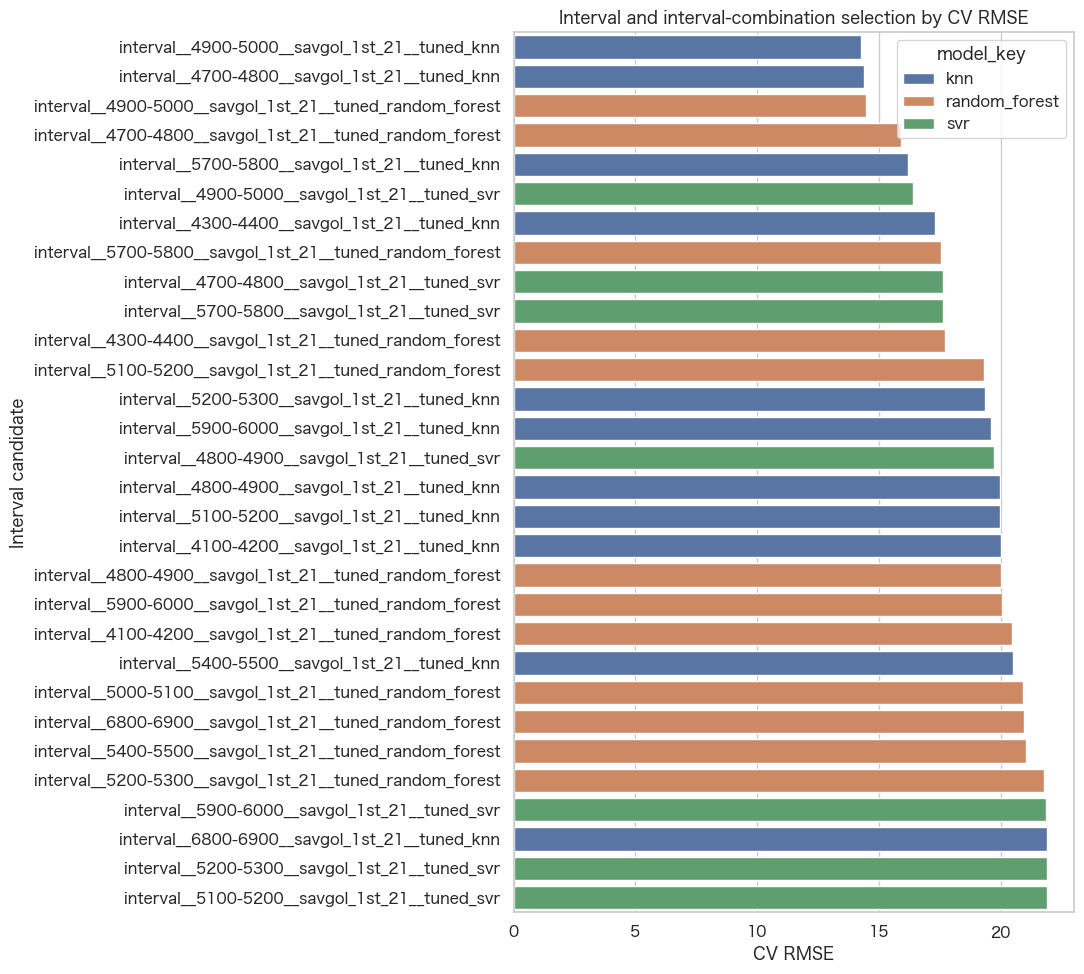

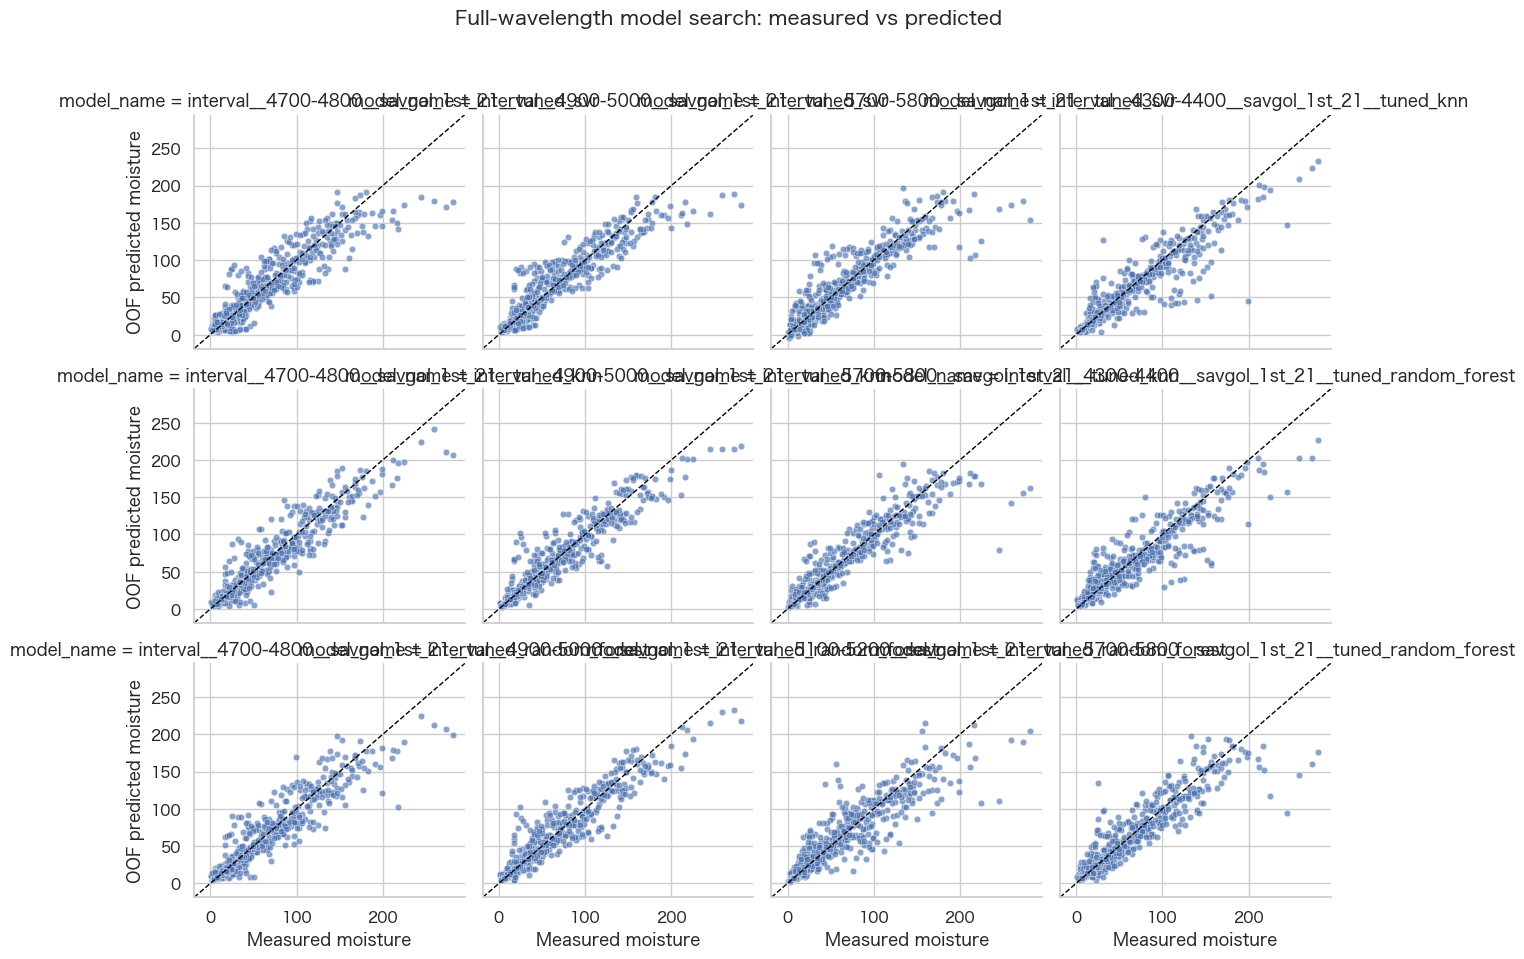

In [13]:
if not interval_scores_df.empty:
    interval_plot = interval_scores_df.dropna(subset=['rmse']).head(30).copy()
    fig, ax = plt.subplots(figsize=(11, max(5, 0.33 * len(interval_plot))))
    sns.barplot(data=interval_plot, y='model_name', x='rmse', hue='model_key', dodge=False, ax=ax)
    ax.set_title('Interval and interval-combination selection by CV RMSE')
    ax.set_xlabel('CV RMSE')
    ax.set_ylabel('Interval candidate')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{PREFIX}_interval_selection_cv_rmse.png', dpi=160)

    interval_oof_plot_df = plot_oof_scatter_for_models(interval_oof_df, interval_scores_df, PREFIX + '_interval', top_n=12)
else:
    interval_oof_plot_df = pd.DataFrame()


## 5. valid確認

valid: full__savgol_1st_21__tuned_svr
valid: full__savgol_1st_21__tuned_knn
valid: full__savgol_1st_21__tuned_random_forest
valid: full__snv_savgol_2nd_21__tuned_knn
valid: full__snv_savgol_2nd_21__tuned_random_forest


/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ogawatomohiro/myproject/

valid: full__snv_savgol_2nd_21__tuned_ridge
valid: full__savgol_1st_21__tuned_ridge
valid: full__snv_savgol_2nd_21__tuned_svr
valid: full__savgol_1st_21__tuned_pls
valid: full__snv_savgol_2nd_21__tuned_pls


,model_name,kind,cv_rmse,r2,rmse,mae
2,full__savgol_1st_21__tuned_random_forest,full_wavelength,7.991640,0.973885,7.968862,3.286176
1,full__savgol_1st_21__tuned_knn,full_wavelength,6.402035,0.970712,8.439030,2.413852
0,full__savgol_1st_21__tuned_svr,full_wavelength,5.441828,0.968307,8.778666,2.363466
7,full__snv_savgol_2nd_21__tuned_svr,full_wavelength,11.564211,0.961608,9.662007,3.811519
3,full__snv_savgol_2nd_21__tuned_knn,full_wavelength,9.157309,0.956992,10.226368,3.642726
6,full__savgol_1st_21__tuned_ridge,full_wavelength,11.258442,0.956384,10.298479,6.977777
4,full__snv_savgol_2nd_21__tuned_random_forest,full_wavelength,9.852828,0.953523,10.630824,4.458299
5,full__snv_savgol_2nd_21__tuned_ridge,full_wavelength,11.144711,0.947948,11.250382,6.973470
8,full__savgol_1st_21__tuned_pls,full_wavelength,12.726217,0.944784,11.587247,8.549691
9,full__snv_savgol_2nd_21__tuned_pls,full_wavelength,13.755462,0.900381,15.563919,10.392813


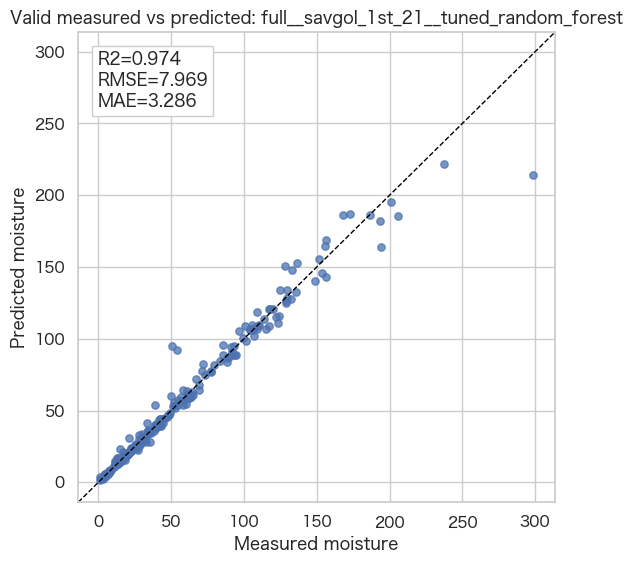

In [14]:
def predict_candidate(estimator, X_fit, y_fit, X_pred):
    est = clone(estimator)
    est.fit(X_fit, y_fit)
    return np.asarray(est.predict(X_pred)).ravel(), est

valid_rows = []
valid_pred_map = {}
valid_estimator_map = {}
if not model_scores.empty:
    for _, row in model_scores.dropna(subset=['rmse']).head(TOP_MODELS_FOR_VALID_CHECK).iterrows():
        name = row['model_name']
        if name not in candidate_registry:
            continue
        print(f'valid: {name}')
        pred, fitted = predict_candidate(candidate_registry[name], X_train, y_train, X_valid)
        valid_pred_map[name] = pred
        valid_estimator_map[name] = fitted
        valid_rows.append({'model_name': name, 'kind': row.get('stage', 'single'), 'cv_rmse': row['rmse'], **regression_metrics(y_valid, pred)})
valid_scores = pd.DataFrame(valid_rows).sort_values('rmse') if valid_rows else pd.DataFrame()
valid_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_valid_scores.csv', index=False, encoding='utf-8-sig')
display(valid_scores)

if not valid_scores.empty:
    best_valid_name = valid_scores.iloc[0]['model_name']
    pred = valid_pred_map[best_valid_name]
    fig, ax = plt.subplots(figsize=(5.8, 5.8))
    ax.scatter(y_valid, pred, s=28, alpha=0.75)
    low = min(y_valid.min(), pred.min())
    high = max(y_valid.max(), pred.max())
    pad = (high - low) * 0.05 if high > low else 1
    ax.plot([low - pad, high + pad], [low - pad, high + pad], color='black', linestyle='--', linewidth=1)
    ax.set_xlim(low - pad, high + pad)
    ax.set_ylim(low - pad, high + pad)
    ax.set_xlabel('Measured moisture')
    ax.set_ylabel('Predicted moisture')
    ax.set_title(f'Valid measured vs predicted: {best_valid_name}')
    m = regression_metrics(y_valid, pred)
    ax.text(0.04, 0.96, f"R2={m['r2']:.3f}\nRMSE={m['rmse']:.3f}\nMAE={m['mae']:.3f}", transform=ax.transAxes, va='top', bbox={'facecolor': 'white', 'edgecolor': '#cccccc'})
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{PREFIX}_valid_best_measured_vs_predicted.png', dpi=160)
else:
    best_valid_name = None


## 6. アンサンブル / Stacking

OOF 予測を使って、上位モデルの単純平均・RMSE逆数重み平均・Ridge stacking を比較します。valid でも同じメンバー構成で確認します。

In [15]:
def ensemble_oof_scores(oof_df, scores_df, top_n=TOP_MODELS_FOR_ENSEMBLE):
    base = oof_df.dropna(subset=['oof_pred']).copy()
    if base.empty:
        return pd.DataFrame(), {}
    pivot = base.pivot_table(index='sample_id', columns='model_name', values='oof_pred', aggfunc='first')
    y_map = base.drop_duplicates('sample_id').set_index('sample_id')['y_true']
    top = [m for m in scores_df.dropna(subset=['rmse']).head(top_n)['model_name'] if m in pivot.columns]
    rows = []
    recipes = {}
    for n in [3, 5, 8, min(top_n, len(top))]:
        members = top[:n]
        if len(members) < 2:
            continue
        pred_mean = pivot[members].mean(axis=1)
        name = f'ensemble_mean_top{len(members)}'
        rows.append({'model_name': name, 'members': ','.join(members), **regression_metrics(y_map.loc[pred_mean.index], pred_mean)})
        recipes[name] = {'method': 'mean', 'members': members, 'weights': None, 'model': None}

        weights = 1 / scores_df.set_index('model_name').loc[members, 'rmse'].clip(lower=1e-9)
        weights = weights / weights.sum()
        pred_weighted = pivot[members].mul(weights, axis=1).sum(axis=1)
        name = f'ensemble_weighted_top{len(members)}'
        rows.append({'model_name': name, 'members': ','.join(members), **regression_metrics(y_map.loc[pred_weighted.index], pred_weighted)})
        recipes[name] = {'method': 'weighted', 'members': members, 'weights': weights, 'model': None}

        complete = pivot[members].dropna()
        stack_oof = pd.Series(np.nan, index=complete.index, dtype=float)
        stack_cv = KFold(n_splits=min(N_SPLITS, len(complete)), shuffle=True, random_state=RANDOM_STATE)
        for tr_idx, va_idx in stack_cv.split(complete):
            stacker = Ridge(alpha=1.0)
            stacker.fit(complete.iloc[tr_idx], y_map.loc[complete.index[tr_idx]])
            stack_oof.iloc[va_idx] = stacker.predict(complete.iloc[va_idx])
        final_stacker = Ridge(alpha=1.0).fit(complete, y_map.loc[complete.index])
        name = f'ensemble_ridge_stack_top{len(members)}'
        rows.append({'model_name': name, 'members': ','.join(members), **regression_metrics(y_map.loc[stack_oof.index], stack_oof)})
        recipes[name] = {'method': 'ridge_stack', 'members': members, 'weights': None, 'model': final_stacker}
    result = pd.DataFrame(rows)
    return (result.sort_values('rmse') if not result.empty else result), recipes

ensemble_scores = pd.DataFrame()
ensemble_recipe = {}
valid_ensemble_scores = pd.DataFrame()

if RUN_ENSEMBLE and not oof_df.empty and not model_scores.empty:
    ensemble_scores, ensemble_recipe = ensemble_oof_scores(oof_df, model_scores)
    ensemble_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_ensemble_scores_cv.csv', index=False, encoding='utf-8-sig')
    display(ensemble_scores)

    valid_ensemble_rows = []
    for ens_name, recipe in ensemble_recipe.items():
        members = recipe['members']
        member_preds = pd.DataFrame({m: valid_pred_map[m] for m in members if m in valid_pred_map})
        if member_preds.shape[1] != len(members):
            continue
        if recipe['method'] == 'mean':
            pred = member_preds[members].mean(axis=1).values
        elif recipe['method'] == 'weighted':
            pred = member_preds[members].mul(recipe['weights'].loc[members], axis=1).sum(axis=1).values
        elif recipe['method'] == 'ridge_stack':
            pred = recipe['model'].predict(member_preds[members])
        else:
            continue
        valid_pred_map[ens_name] = pred
        valid_ensemble_rows.append({'model_name': ens_name, 'kind': 'ensemble', 'cv_rmse': ensemble_scores.set_index('model_name').loc[ens_name, 'rmse'], **regression_metrics(y_valid, pred)})
    valid_ensemble_scores = pd.DataFrame(valid_ensemble_rows).sort_values('rmse') if valid_ensemble_rows else pd.DataFrame()
    valid_ensemble_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_valid_ensemble_scores.csv', index=False, encoding='utf-8-sig')
    display(valid_ensemble_scores)

all_valid_scores = pd.concat([valid_scores, valid_ensemble_scores], ignore_index=True, sort=False).sort_values('rmse') if not valid_scores.empty else valid_ensemble_scores
all_valid_scores.to_csv(OUTPUT_DIR / f'{PREFIX}_all_valid_scores.csv', index=False, encoding='utf-8-sig')
display(all_valid_scores.head(20))


,model_name,members,r2,rmse,mae
2,ensemble_ridge_stack_top3,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.989614,4.947603,2.547765
8,ensemble_ridge_stack_top6,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.989556,4.961433,2.592845
11,ensemble_ridge_stack_top6,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.989556,4.961433,2.592845
5,ensemble_ridge_stack_top5,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.989555,4.961619,2.583662
1,ensemble_weighted_top3,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.987268,5.477923,2.570533
0,ensemble_mean_top3,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.986571,5.625839,2.655036
4,ensemble_weighted_top5,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.983618,6.213736,2.867580
7,ensemble_weighted_top6,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.983163,6.299408,3.136005
10,ensemble_weighted_top6,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.983163,6.299408,3.136005
3,ensemble_mean_top5,"full__savgol_1st_21__tuned_svr,full__savgol_1s...",0.981544,6.595333,3.049490


,model_name,kind,cv_rmse,r2,rmse,mae
0,ensemble_mean_top3,ensemble,5.625839,0.976259,7.597922,2.216041
1,ensemble_weighted_top3,ensemble,5.477923,0.975746,7.679670,2.159368
8,ensemble_ridge_stack_top6,ensemble,model_name ensemble_ridge_stack_top6 4.9614...,0.974391,7.891226,2.410025
5,ensemble_ridge_stack_top5,ensemble,4.961619,0.974303,7.904727,2.398917
2,ensemble_ridge_stack_top3,ensemble,4.947603,0.973709,7.995604,2.444789
7,ensemble_weighted_top6,ensemble,model_name ensemble_weighted_top6 6.299408 ...,0.972682,8.150342,2.711777
4,ensemble_weighted_top5,ensemble,6.213736,0.972598,8.162775,2.510803
6,ensemble_mean_top6,ensemble,model_name ensemble_mean_top6 6.705291 ense...,0.971598,8.310424,2.982057
3,ensemble_mean_top5,ensemble,6.595333,0.971496,8.325358,2.673329


,model_name,kind,cv_rmse,r2,rmse,mae
10,ensemble_mean_top3,ensemble,5.625839,0.976259,7.597922,2.216041
11,ensemble_weighted_top3,ensemble,5.477923,0.975746,7.679670,2.159368
12,ensemble_ridge_stack_top6,ensemble,model_name ensemble_ridge_stack_top6 4.9614...,0.974391,7.891226,2.410025
13,ensemble_ridge_stack_top5,ensemble,4.961619,0.974303,7.904727,2.398917
0,full__savgol_1st_21__tuned_random_forest,full_wavelength,7.99164,0.973885,7.968862,3.286176
14,ensemble_ridge_stack_top3,ensemble,4.947603,0.973709,7.995604,2.444789
15,ensemble_weighted_top6,ensemble,model_name ensemble_weighted_top6 6.299408 ...,0.972682,8.150342,2.711777
16,ensemble_weighted_top5,ensemble,6.213736,0.972598,8.162775,2.510803
17,ensemble_mean_top6,ensemble,model_name ensemble_mean_top6 6.705291 ense...,0.971598,8.310424,2.982057
18,ensemble_mean_top5,ensemble,6.595333,0.971496,8.325358,2.673329


## 7. test 最終評価と保存

In [16]:
def fit_single_or_ensemble(selected_name, train_valid_df):
    X_train_valid, y_train_valid = get_xy(train_valid_df, spectral_cols, target_col)
    if selected_name in candidate_registry:
        est = clone(candidate_registry[selected_name])
        est.fit(X_train_valid, y_train_valid)
        return {'kind': 'single', 'name': selected_name, 'model': est}
    if selected_name in ensemble_recipe:
        recipe = ensemble_recipe[selected_name]
        fitted_members = {}
        train_valid_member_preds = pd.DataFrame(index=np.arange(len(train_valid_df)))
        for member in recipe['members']:
            est = clone(candidate_registry[member])
            est.fit(X_train_valid, y_train_valid)
            fitted_members[member] = est
            train_valid_member_preds[member] = np.asarray(est.predict(X_train_valid)).ravel()
        stack_model = None
        if recipe['method'] == 'ridge_stack':
            stack_model = Ridge(alpha=1.0).fit(train_valid_member_preds[recipe['members']], y_train_valid)
        return {'kind': 'ensemble', 'name': selected_name, 'recipe': recipe, 'members': fitted_members, 'stack_model': stack_model}
    raise KeyError(selected_name)


def predict_single_or_ensemble(bundle, X):
    if bundle['kind'] == 'single':
        return np.asarray(bundle['model'].predict(X)).ravel()
    recipe = bundle['recipe']
    member_preds = pd.DataFrame({m: np.asarray(bundle['members'][m].predict(X)).ravel() for m in recipe['members']})
    if recipe['method'] == 'mean':
        return member_preds[recipe['members']].mean(axis=1).values
    if recipe['method'] == 'weighted':
        return member_preds[recipe['members']].mul(recipe['weights'].loc[recipe['members']], axis=1).sum(axis=1).values
    if recipe['method'] == 'ridge_stack':
        return bundle['stack_model'].predict(member_preds[recipe['members']])
    raise KeyError(recipe['method'])

if all_valid_scores.empty:
    raise ValueError('No valid scores available. Run model search first.')

selected_name = all_valid_scores.iloc[0]['model_name']
train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)
X_train_valid, y_train_valid = get_xy(train_valid_df, spectral_cols, target_col)

if not RUN_FINAL_TEST:
    final_bundle = None
    test_pred = None
    test_metrics = None
    prediction_df = pd.DataFrame()
    manifest = pd.DataFrame([{
        'selected_model': selected_name,
        'status': 'final_test_skipped',
        'reason': 'RUN_FINAL_TEST is False',
        'data_path': config['data_path'],
        'n_spectral_cols': config['n_spectral_cols'],
    }])
    manifest.to_csv(OUTPUT_DIR / f'{PREFIX}_final_model_manifest_skipped.csv', index=False, encoding='utf-8-sig')
    write_run_config({'selected_model_before_final_test': selected_name, 'final_test_skipped': True})
    print(f'RUN_FINAL_TEST=False: test evaluation and final model pickle were skipped. Selected valid candidate: {selected_name}')
    display(manifest)
else:
    final_bundle = fit_single_or_ensemble(selected_name, train_valid_df)
    test_pred = predict_single_or_ensemble(final_bundle, X_test)
    test_metrics = regression_metrics(y_test, test_pred)
    print(json.dumps({'selected_model': selected_name, **test_metrics}, ensure_ascii=False, indent=2))

    prediction_df = pd.DataFrame({
        'sample_id': sample_ids(test_df, sample_col),
        'split': 'test',
        'model_name': selected_name,
        'measured_moisture': y_test.values,
        'predicted_moisture': test_pred,
        'residual': y_test.values - test_pred,
    })
    if group_col is not None and group_col in test_df.columns:
        prediction_df['diagnostic_group'] = test_df[group_col].astype(str).values
    prediction_df.to_csv(OUTPUT_DIR / f'{PREFIX}_test_predictions.csv', index=False, encoding='utf-8-sig')

    manifest = pd.DataFrame([{
        'selected_model': selected_name,
        'kind': final_bundle['kind'],
        **test_metrics,
        'data_path': config['data_path'],
        'n_spectral_cols': config['n_spectral_cols'],
    }])
    manifest.to_csv(OUTPUT_DIR / f'{PREFIX}_final_model_manifest.csv', index=False, encoding='utf-8-sig')
    with open(OUTPUT_DIR / f'{PREFIX}_final_model.pkl', 'wb') as f:
        pickle.dump({'bundle': final_bundle, 'spectral_cols': spectral_cols, 'spec_info': spec_info, 'config': config, 'selected_model_name': selected_name}, f)
    write_run_config({'selected_model': selected_name, 'test_metrics': test_metrics, 'final_test_skipped': False})

    display(manifest)
    display(prediction_df.head())


RUN_FINAL_TEST=False: test evaluation and final model pickle were skipped. Selected valid candidate: ensemble_mean_top3


,selected_model,status,reason,data_path,n_spectral_cols
0,ensemble_mean_top3,final_test_skipped,RUN_FINAL_TEST is False,/Users/ogawatomohiro/myproject/data/train.csv,1555


## 8. 最終診断プロット

In [17]:
if not RUN_FINAL_TEST or final_bundle is None or prediction_df.empty:
    print('Final diagnostics skipped because RUN_FINAL_TEST is False or no test predictions are available.')
else:
    train_valid_pred = predict_single_or_ensemble(final_bundle, X_train_valid)
    valid_pred_final = valid_pred_map[selected_name] if selected_name in valid_pred_map else np.full(len(y_valid), np.nan)

    plot_sets = [
        ('Train+Valid fit', y_train_valid, train_valid_pred),
        ('Valid selection', y_valid, valid_pred_final),
        ('Final test', y_test, test_pred),
    ]
    all_true = np.concatenate([np.asarray(yv, dtype=float) for _, yv, _ in plot_sets])
    all_pred = np.concatenate([np.asarray(pv, dtype=float) for _, _, pv in plot_sets if np.isfinite(np.asarray(pv, dtype=float)).any()])
    finite_pred = all_pred[np.isfinite(all_pred)]
    low = min(all_true.min(), finite_pred.min())
    high = max(all_true.max(), finite_pred.max())
    pad = (high - low) * 0.05 if high > low else 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (title, y_true_plot, y_pred_plot) in zip(axes, plot_sets):
        y_pred_plot = np.asarray(y_pred_plot, dtype=float)
        mask = np.isfinite(y_pred_plot)
        if mask.any():
            m = regression_metrics(np.asarray(y_true_plot)[mask], y_pred_plot[mask])
            ax.scatter(np.asarray(y_true_plot)[mask], y_pred_plot[mask], s=26, alpha=0.75)
            ax.text(0.04, 0.96, f"R2={m['r2']:.3f}\nRMSE={m['rmse']:.3f}\nMAE={m['mae']:.3f}", transform=ax.transAxes, va='top', bbox={'facecolor': 'white', 'edgecolor': '#cccccc'})
        ax.plot([low - pad, high + pad], [low - pad, high + pad], color='black', linestyle='--', linewidth=1)
        ax.set_xlim(low - pad, high + pad)
        ax.set_ylim(low - pad, high + pad)
        ax.set_xlabel('Measured moisture')
        ax.set_ylabel('Predicted moisture')
        ax.set_title(title)
    fig.suptitle(f'04 final diagnostics: {selected_name}', y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{PREFIX}_final_measured_vs_predicted.png', dpi=160)

    analysis_df = prediction_df.copy()
    analysis_df['absolute_error'] = analysis_df['residual'].abs()
    analysis_df['squared_error'] = analysis_df['residual'] ** 2
    analysis_df.to_csv(OUTPUT_DIR / f'{PREFIX}_selected_model_prediction_analysis.csv', index=False, encoding='utf-8-sig')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.scatterplot(data=analysis_df, x='predicted_moisture', y='residual', s=35, alpha=0.8, ax=axes[0])
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title('Test residuals')
    axes[0].set_xlabel('Predicted moisture')
    axes[0].set_ylabel('Measured - predicted')
    sns.histplot(data=analysis_df, x='residual', kde=True, ax=axes[1])
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Test residual distribution')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{PREFIX}_test_residual_diagnostics.png', dpi=160)


Final diagnostics skipped because RUN_FINAL_TEST is False or no test predictions are available.
